In [10]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/Concrete_Data.xls'
data = pd.read_excel(file_path)
display(data)


Mounted at /content/drive


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


## Data Preprocessing

This step involves checking for missing values and outliers, and handling them appropriately.

In [12]:
# Check for missing values
print("Missing values before handling:")
display(data.isnull().sum())

# Depending on the output, you can choose a strategy to handle missing values.
# For example, drop rows with missing values:
# data.dropna(inplace=True)

# Or, fill missing values with the mean of the column:
# data.fillna(data.mean(), inplace=True)

# Check for outliers (example using describe() and visual inspection later)
print("\nData description (check for potential outliers in min/max values):")
display(data.describe())

# Note: Outlier handling strategy depends on the data and the chosen model.
# You might use techniques like z-score, IQR, or visualization to identify and handle outliers.

Missing values before handling:


,0
Cement (component 1)(kg in a m^3 mixture),0
Blast Furnace Slag (component 2)(kg in a m^3 mixture),0
Fly Ash (component 3)(kg in a m^3 mixture),0
Water (component 4)(kg in a m^3 mixture),0
Superplasticizer (component 5)(kg in a m^3 mixture),0
Coarse Aggregate (component 6)(kg in a m^3 mixture),0
Fine Aggregate (component 7)(kg in a m^3 mixture),0
Age (day),0
"Concrete compressive strength(MPa, megapascals)",0



Data description (check for potential outliers in min/max values):


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [13]:
# Separate features (X) and target variable (y)
X = data.drop('Concrete compressive strength(MPa, megapascals) ', axis=1)
y = data['Concrete compressive strength(MPa, megapascals) ']

## Data Visualization

Let's visualize the data to understand the relationships between the features and the target variable.

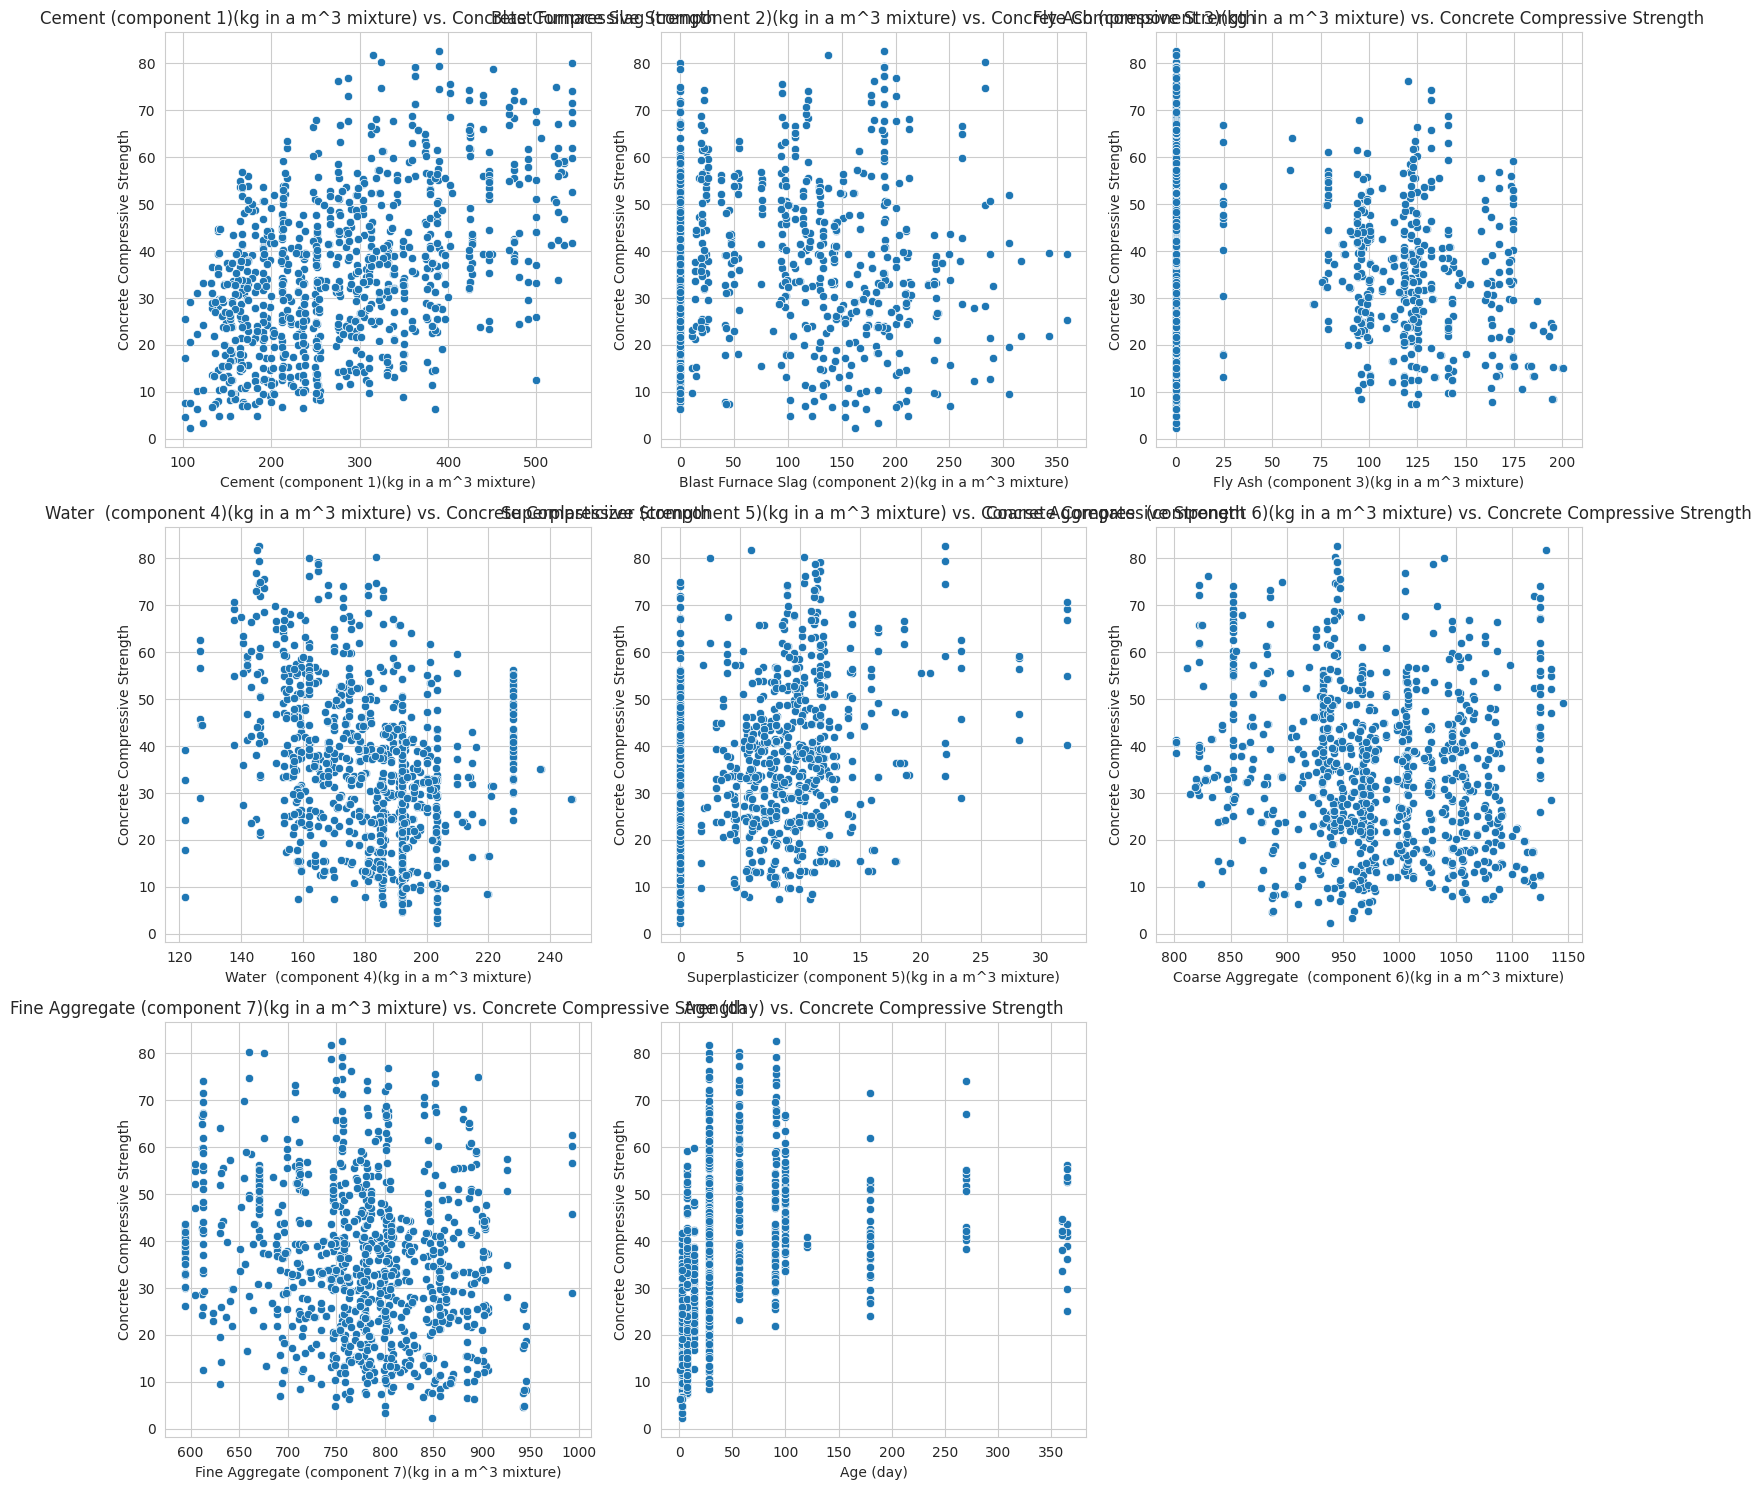

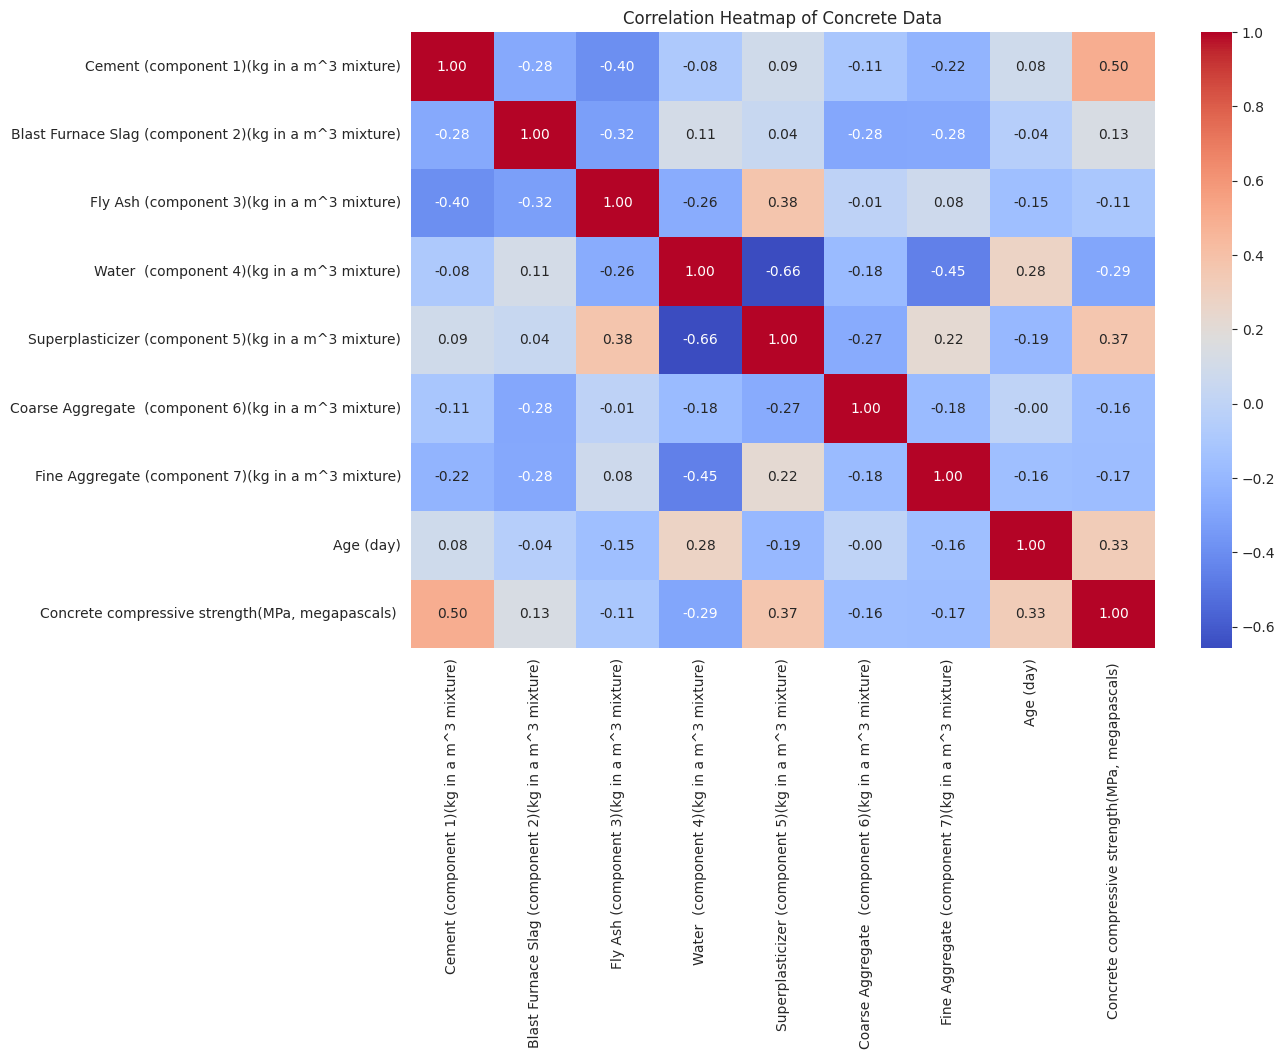

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Scatter plots of features vs. target variable
features = X.columns
num_features = len(features)
rows = (num_features + 2) // 3
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(x=data[feature], y=data['Concrete compressive strength(MPa, megapascals) '], ax=axes[i])
    axes[i].set_title(f'{feature} vs. Concrete Compressive Strength')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Concrete Compressive Strength')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Concrete Data')
plt.show()

## Model Selection and Training

Now we will train the selected regression models on the prepared data.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

# Separate features (X) and target variable (y) - Already done, but included for completeness
X = data.drop('Concrete compressive strength(MPa, megapascals) ', axis=1)
y = data['Concrete compressive strength(MPa, megapascals) ']

# Split data into training and testing sets - Already done, but included for completeness
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "SVM": SVR()
}

trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

print("\nAll models trained successfully!")

Training Linear Regression...
Linear Regression trained.
Training Decision Tree...
Decision Tree trained.
Training Random Forest...
Random Forest trained.
Training XGBoost...
XGBoost trained.
Training SVM...
SVM trained.

All models trained successfully!


## Model Evaluation

Now, we will evaluate the performance of each trained model using metrics such as R², Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

In [18]:
# Model Evaluation
results = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)**0.5 # Calculate RMSE by taking the square root of MSE

    results[name] = {
        "R2 Score": r2,
        "MSE": mse,
        "RMSE": rmse
    }

# Display evaluation results
print("Model Evaluation Results:")
for name, metrics in results.items():
    print(f"\n{name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

Model Evaluation Results:

Linear Regression:
  R2 Score: 0.6275
  MSE: 95.9755
  RMSE: 9.7967

Decision Tree:
  R2 Score: 0.7917
  MSE: 53.6732
  RMSE: 7.3262

Random Forest:
  R2 Score: 0.8822
  MSE: 30.3581
  RMSE: 5.5098

XGBoost:
  R2 Score: 0.9231
  MSE: 19.8221
  RMSE: 4.4522

SVM:
  R2 Score: 0.2320
  MSE: 197.8923
  RMSE: 14.0674


## Hyperparameter Tuning

Let's tune the hyperparameters of the XGBoost model to potentially improve its performance. We will use `GridSearchCV` for this.

In [19]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define the parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Initialize the XGBoost Regressor
xgb_model = xgb.XGBRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='neg_mean_squared_error', cv=5, verbose=2, n_jobs=-1)

# Perform the grid search
print("Performing GridSearchCV for XGBoost...")
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("\nBest parameters found: ", grid_search.best_params_)
print("Best negative MSE found: ", grid_search.best_score_)

# The best estimator
best_xgb_model = grid_search.best_estimator_

Performing GridSearchCV for XGBoost...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best parameters found:  {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.9}
Best negative MSE found:  -19.068345767071396


## Evaluate Tuned XGBoost Model

Let's evaluate the performance of the XGBoost model with the tuned hyperparameters.

In [21]:
# Evaluate the tuned XGBoost model
y_pred_tuned_xgb = best_xgb_model.predict(X_test)

r2_tuned_xgb = r2_score(y_test, y_pred_tuned_xgb)
mse_tuned_xgb = mean_squared_error(y_test, y_pred_tuned_xgb)
rmse_tuned_xgb = mean_squared_error(y_test, y_pred_tuned_xgb)**0.5 # Calculate RMSE

print("Tuned XGBoost Model Evaluation Results:")
print(f"  R2 Score: {r2_tuned_xgb:.4f}")
print(f"  MSE: {mse_tuned_xgb:.4f}")
print(f"  RMSE: {rmse_tuned_xgb:.4f}")

# Compare with original XGBoost model results
original_xgb_results = results["XGBoost"]
print("\nOriginal XGBoost Model Evaluation Results:")
print(f"  R2 Score: {original_xgb_results['R2 Score']:.4f}")
print(f"  MSE: {original_xgb_results['MSE']:.4f}")
print(f"  RMSE: {original_xgb_results['RMSE']:.4f}")

Tuned XGBoost Model Evaluation Results:
  R2 Score: 0.9289
  MSE: 18.3116
  RMSE: 4.2792

Original XGBoost Model Evaluation Results:
  R2 Score: 0.9231
  MSE: 19.8221
  RMSE: 4.4522


## Feature Importance Analysis

Let's analyze the importance of each feature in the best-performing model (tuned XGBoost).

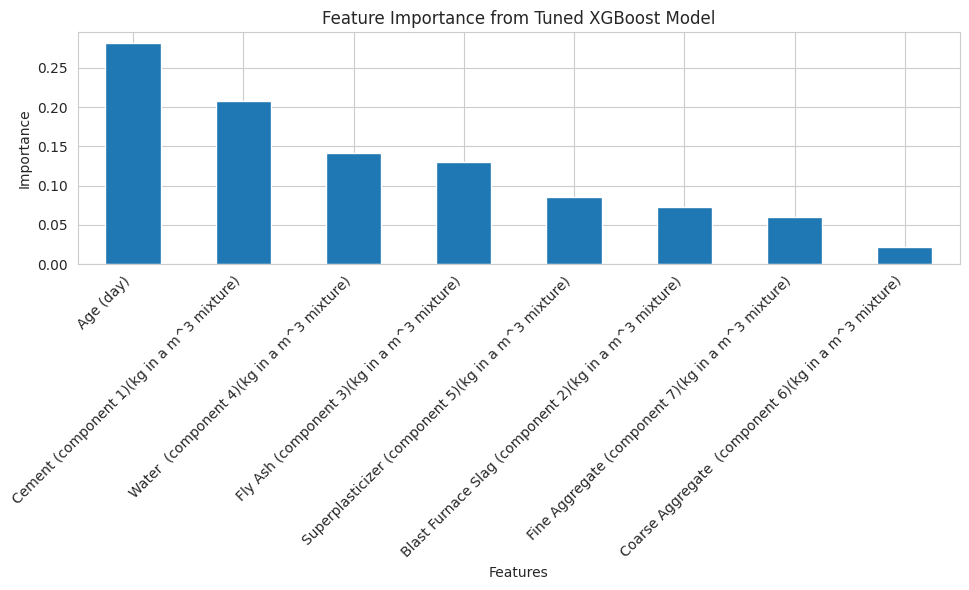


Feature Importances (sorted):


,0
Age (day),0.280985
Cement (component 1)(kg in a m^3 mixture),0.207366
Water (component 4)(kg in a m^3 mixture),0.141468
Fly Ash (component 3)(kg in a m^3 mixture),0.130274
Superplasticizer (component 5)(kg in a m^3 mixture),0.085731
Blast Furnace Slag (component 2)(kg in a m^3 mixture),0.072387
Fine Aggregate (component 7)(kg in a m^3 mixture),0.060031
Coarse Aggregate (component 6)(kg in a m^3 mixture),0.021758


In [22]:
# Get feature importances from the tuned XGBoost model
feature_importances = best_xgb_model.feature_importances_

# Create a pandas Series for easier visualization
feature_importance_series = pd.Series(feature_importances, index=X_train.columns)

# Sort the features by importance
sorted_feature_importance = feature_importance_series.sort_values(ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sorted_feature_importance.plot(kind='bar')
plt.title('Feature Importance from Tuned XGBoost Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nFeature Importances (sorted):")
display(sorted_feature_importance)

## Results and Conclusion

Based on the model evaluation and feature importance analysis, summarize your findings here.

**Model Performance:**

*   Compare the performance of the different models (Linear Regression, Decision Tree, Random Forest, XGBoost, SVM, and Tuned XGBoost) based on the R², MSE, and RMSE scores.
*   Identify the best-performing model.

**Feature Importance:**

*   Discuss the features that the best model identified as most important for predicting concrete compressive strength.
*   Relate these findings back to your understanding of concrete properties if possible.

**Overall Conclusion:**

*   Summarize what you have learned from this project about predicting concrete compressive strength using machine learning.
*   Mention any potential next steps or areas for further improvement.

## Model Prediction Visualizations

Let's visualize the predictions of each trained model against the actual values on the test set to gain more insight into their performance.

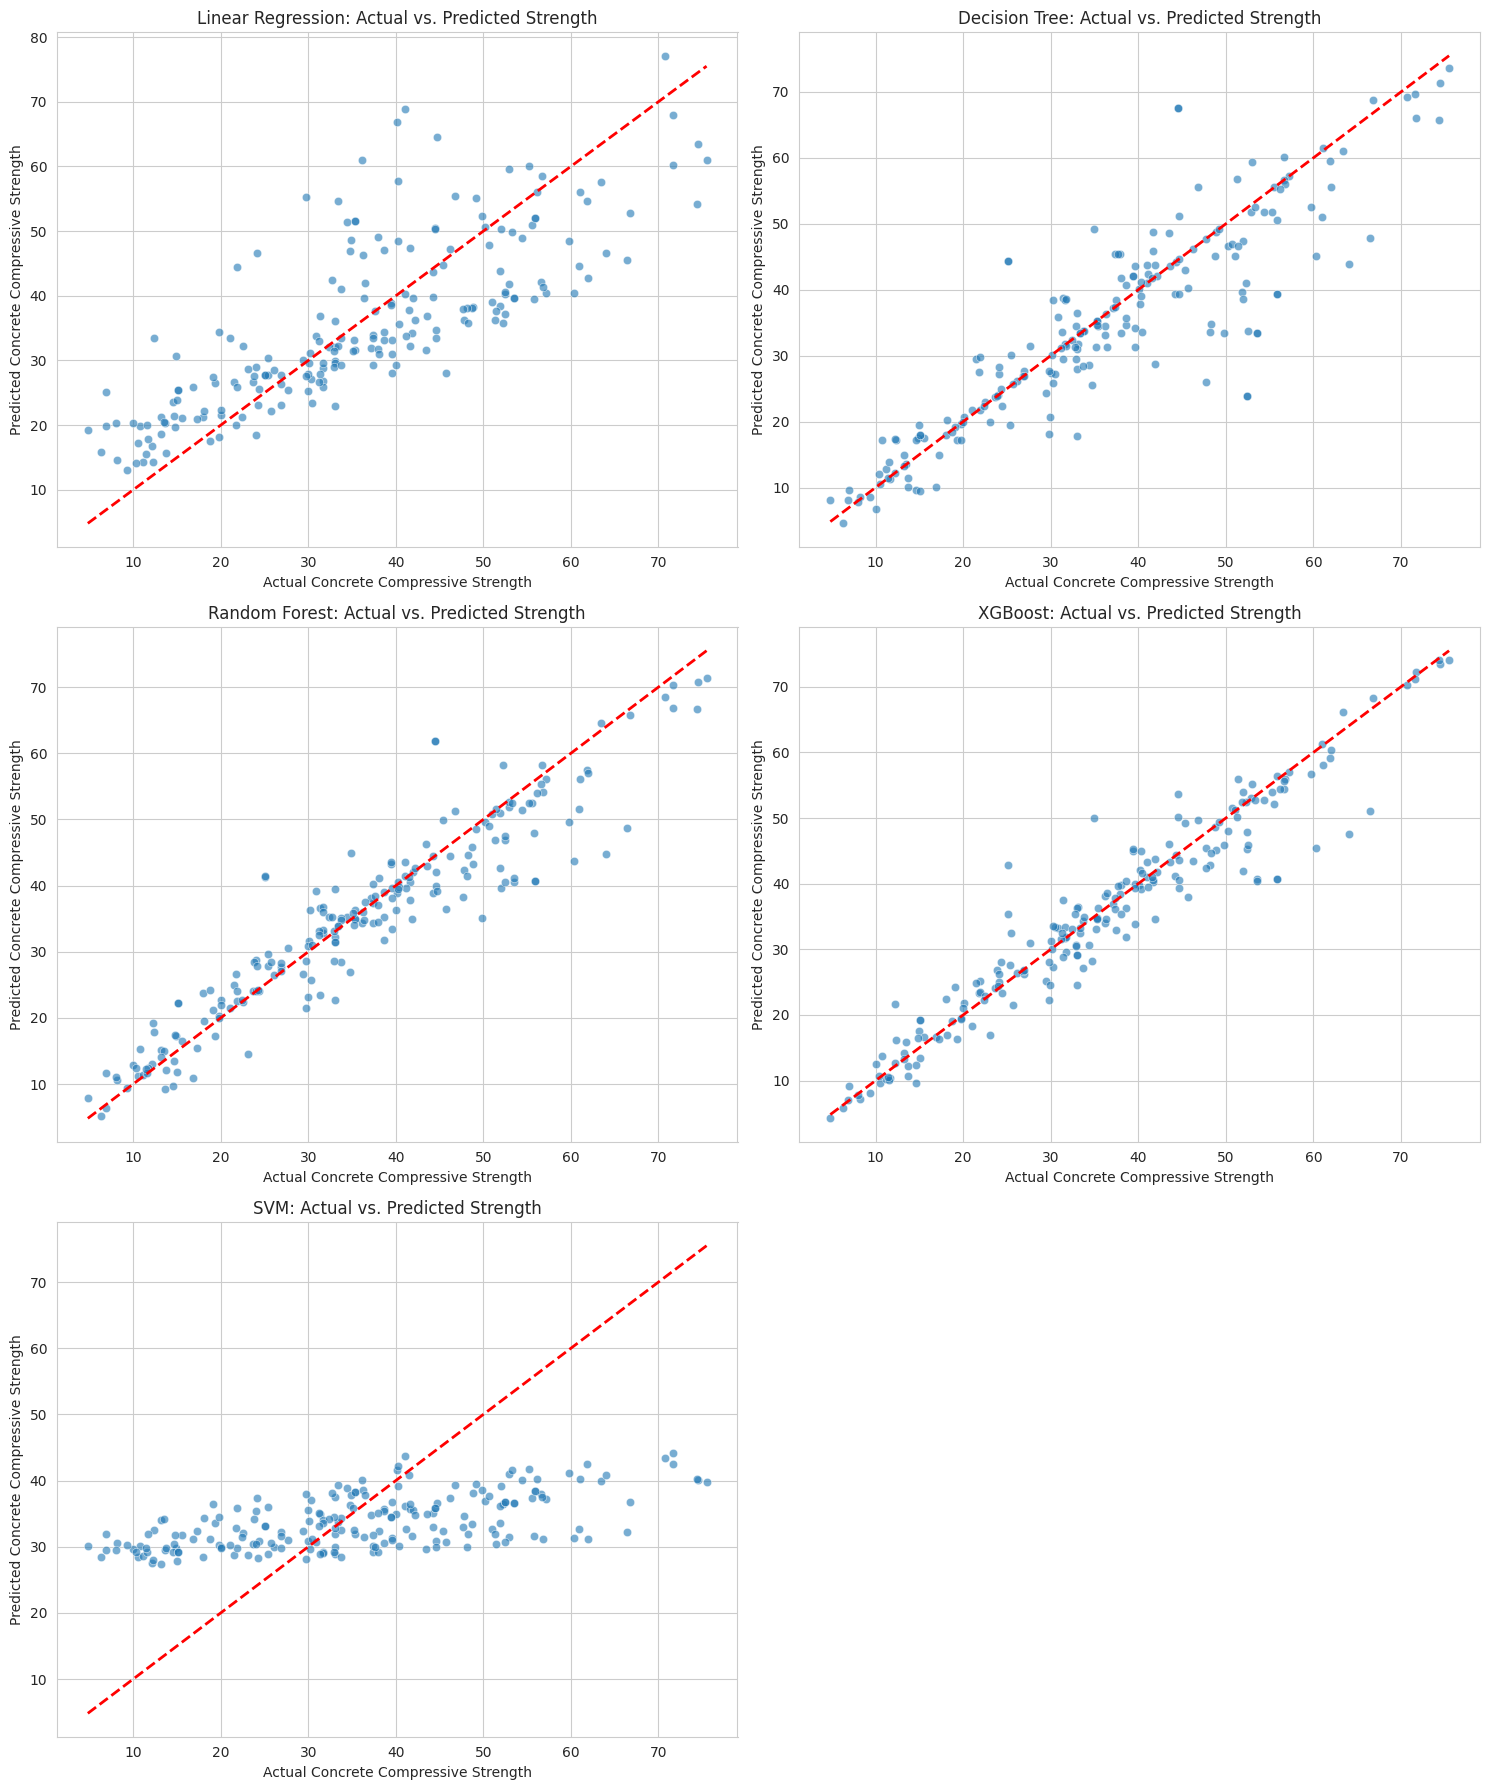

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Get the list of trained models
models_to_visualize = trained_models.keys()
num_models = len(models_to_visualize)

# Determine the layout of the subplots
rows = (num_models + 1) // 2  # Arrange in 2 columns
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 6))
axes = axes.flatten()

# Plot actual vs. predicted for each model
for i, name in enumerate(models_to_visualize):
    model = trained_models[name]
    y_pred = model.predict(X_test)

    ax = axes[i]
    sns.scatterplot(x=y_test, y=y_pred, ax=ax, alpha=0.6)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Add a diagonal line
    ax.set_title(f'{name}: Actual vs. Predicted Strength')
    ax.set_xlabel('Actual Concrete Compressive Strength')
    ax.set_ylabel('Predicted Concrete Compressive Strength')
    ax.grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()